# ML Model

### The task

**Build a machine learning model to forecast life expectancy at birth for each country from 2010 to 2023, using only data available up to and including 2010.**

**The objective is to assess how accurately future life expectancy trends can be predicted using historical information from the provided World Bank datasets.**

**Document how well the model performed when compared with the ground truth as well as challenges and ideas for future improvement for the model.**

**Datasets used**:
- `total_life_expectancy_at_birth.csv` (target)
- `male_life_expectancy_at_birth.csv`, `female_life_expectancy_at_birth.csv`
- `death_rate_crude.csv`
- `fertility_rate_total.csv`
- `country_metadata.csv` 

**Notebook structure:**
1. Data Loading & Preparation
2. Feature engineering
3. Model Training & Comparing Models
4. Forecasting for 2011–2023
5. Evaluation
6. Insights, Challenges & Ideas for Future Improvement

In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

In [2]:
DATA_DIR = "../data"
OUT_DIR = "model_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
pd.set_option("display.max_columns", 50)

## 1. Data Loading & Preparation

The data CSVs have 4 header rows, then one row per country/aggregated nations with one column
per year (1960–2025, mostly empty for 2025). We reshape each indicator to long format
(`Country Code`, `Year`, value) and merge them all together, then inner-join with
`country_metadata.csv` which only has a non-null `IncomeGroup` for actual countries. This we do to
drop aggregate rows (World, unions, regions, income-group aggregates etc.).

In [3]:
def load_wb_indicator(filename, value_name):
    """
    Load a World Bank 'API' style CSV (4 metadata rows, then a table with
    Country Name / Country Code / Indicator Name / Indicator Code / year columns)
    and reshape it to long format.
    """

    df = pd.read_csv(
        f"{DATA_DIR}/{filename}", skiprows=4
    )  # skip the header rows
    df = df.drop(
        columns=[c for c in df.columns if str(c).startswith("Unnamed")],
        errors="ignore",
    )
    id_cols = ["Country Name", "Country Code"]
    year_cols = [c for c in df.columns if str(c).isdigit()]
    df = df[id_cols + year_cols]
    long = df.melt(id_vars=id_cols, var_name="Year", value_name=value_name)
    long["Year"] = long["Year"].astype(int)
    return long


def load_metadata():
    meta = pd.read_csv(f"{DATA_DIR}/country_metadata.csv")
    meta = meta.drop(
        columns=[c for c in meta.columns if str(c).startswith("Unnamed")],
        errors="ignore",
    )
    # Real countries have a non-null IncomeGroup, aggregates (World, regions,
    # income-group aggregates like "EUU", "World", "Arab World" etc) have an empty IncomeGroup.
    meta = meta[meta["IncomeGroup"].notna()].copy()
    return meta[["Country Code", "Region", "IncomeGroup", "TableName"]]


def build_panel():
    """
    Return one tidy panel:
    Country Code, Country Name, Year, Region, IncomeGroup,
    life_exp, life_exp_male, life_exp_female, death_rate, fertility_rate - restricted
    to actual countries (not aggregates).
    """

    le = load_wb_indicator("total_life_expectancy_at_birth.csv", "life_exp")
    le_m = load_wb_indicator(
        "male_life_expectancy_at_birth.csv", "life_exp_male"
    )
    le_f = load_wb_indicator(
        "female_life_expectancy_at_birth.csv", "life_exp_female"
    )
    dr = load_wb_indicator("death_rate_crude.csv", "death_rate")
    fr = load_wb_indicator("fertility_rate_total.csv", "fertility_rate")

    panel = (
        le.merge(le_m, on=["Country Name", "Country Code", "Year"], how="left")
        .merge(le_f, on=["Country Name", "Country Code", "Year"], how="left")
        .merge(dr, on=["Country Name", "Country Code", "Year"], how="left")
        .merge(fr, on=["Country Name", "Country Code", "Year"], how="left")
    )

    meta = load_metadata()
    panel = panel.merge(
        meta, on="Country Code", how="inner"
    )  # inner merge drops aggregates
    panel = panel.sort_values(["Country Code", "Year"]).reset_index(drop=True)
    return panel


panel = build_panel()
print("Panel shape:", panel.shape)
print("Countries:", panel["Country Code"].nunique())
print("Year range:", panel["Year"].min(), "-", panel["Year"].max())
panel.head()

Panel shape: (14322, 11)
Countries: 217
Year range: 1960 - 2025


,Country Name,Country Code,Year,life_exp,life_exp_male,life_exp_female,death_rate,fertility_rate,Region,IncomeGroup,TableName
0,Aruba,ABW,1960,64.049,60.746,67.459,7.525,4.567,Latin America & Caribbean,High income,Aruba
1,Aruba,ABW,1961,64.215,61.114,67.394,7.347,4.422,Latin America & Caribbean,High income,Aruba
2,Aruba,ABW,1962,64.602,61.371,67.922,7.066,4.262,Latin America & Caribbean,High income,Aruba
3,Aruba,ABW,1963,64.944,61.601,68.389,6.863,4.107,Latin America & Caribbean,High income,Aruba
4,Aruba,ABW,1964,65.303,61.824,68.902,6.689,3.940,Latin America & Caribbean,High income,Aruba


## 2. Feature Engineering




### The Problem
If we only take one data point per country, for example:
- Features at 2010 -> Target at 2023

That gives us just a single training example per country.  
This is too little for a machine learning model to learn meaningful patterns.


### The Solution: Replay History
To mitigate this issue, instead of only using 2010 as the cutoff year, we **replay history** by pretending we are standing in earlier years (1975, 1980, 1995, 2005,...).  

At each cutoff year **Y**:
1. Compute the features that would have been available at that time:
   - Life expectancy level at year Y  
   - 10‑year slope (trend) up to Y  
   - Value 5 years earlier  
   - Fertility rate and death rate (levels and slopes)  
   - Female–male life expectancy gap  
   - Region and income group  

2. Use the **already‑known actual future value** at year **Y + h** (for horizons h = 1, 2, ..., 13 years) as the training label.

### Benefits of this approach
- **No leakage:** We only use information that would have been available at the cutoff year, never future data.  
- **Many examples:** Instead of one row per country, we generate hundreds of examples per country across different cutoff years and horizons.  
- **Horizon awareness:** The model learns how short‑term forecasts differ from long‑term forecasts.  
- **Cross‑country learning:** By replaying history across all countries, the model sees diverse patterns and learns general relationships between past trends and future outcomes.


### Forecasting Step
Finally, we apply the same feature extraction logic once at cutoff = 2010.  
- This produces feature rows for horizons 1, 2, ..., 13 (2011–2023).  
- These rows are fed into the trained model to generate forecasts.




### A Note on Male/Female Life Expectancy and Potential Leakage

In this analysis we deliberately **omit male and female life expectancy series** when forecasting total life expectancy. No features are engineered directly from these values.

The reason is that total life expectancy is itself a weighted combination of male and female life expectancy in the same year. Using them as predictors would be somewhat circular: the model would be learning from variables that are mathematically tied to the target rather than from independent drivers such as fertility, death rates, or regional/income group trends.

While this is not temporal leakage (since the values are contemporaneous at the cutoff year), it could still bias the model by providing information that is too closely related to the target. To avoid this risk and ensure the model learns from genuine explanatory features, we exclude male/female life expectancy from the forecasting pipeline.

The male/female series are still loaded into the broader dataset (`panel`) because they remain useful for other parts of the analysis but **no male/female‑derived feature is used in forecasting total life expectancy**.


In [4]:
# Set configurations for forecasting features and limits
MAX_HORIZON = 13  # 2010 -> 2023
TRAIL_WINDOW = 10  # years of trailing history used for trend features
MIN_CUTOFF = 1975  # earliest cutoff year used to build training examples
TRAIN_CUTOFF_LIMIT = 2010  # never use target years beyond this for training

In [5]:
def slope(years, values):
    """
    OLS slope of values vs years, NaN if fewer than 3 valid points.
    """

    mask = ~np.isnan(values)
    if mask.sum() < 3:
        return np.nan
    return np.polyfit(years[mask], values[mask], 1)[0]


def country_series(country_df):
    """
    Turn a country's rows into a dictionary -> {column: Series indexed by Year}.
    """

    d = country_df.set_index("Year")
    return {
        col: d[col]
        for col in [
            "life_exp",
            "death_rate",
            "fertility_rate",
        ]
    }


def features_at_cutoff(series, cutoff):
    """
    Compute trailing features as of `cutoff`,
    using only years <= cutoff.
    """

    le = series["life_exp"]
    dr = series["death_rate"]
    fr = series["fertility_rate"]

    if cutoff not in le.index or pd.isna(le.get(cutoff, np.nan)):
        return None  # cannot build an example without an anchor value

    window_years = np.arange(cutoff - TRAIL_WINDOW + 1, cutoff + 1)

    def slope_of(s):
        vals = s.reindex(window_years).to_numpy(dtype=float)
        return slope(window_years.astype(float), vals)

    return {
        "life_exp_cutoff": le.get(cutoff, np.nan),
        "life_exp_slope10": slope_of(le),
        "life_exp_5y_ago": le.get(cutoff - 5, np.nan),
        "fert_cutoff": fr.get(cutoff, np.nan),
        "fert_slope10": slope_of(fr),
        "death_cutoff": dr.get(cutoff, np.nan),
        "death_slope10": slope_of(dr),
    }


def build_training_examples(
    panel,
    min_cutoff=MIN_CUTOFF,
    max_horizon=MAX_HORIZON,
    train_cutoff_limit=TRAIN_CUTOFF_LIMIT,
):
    """
    Build the (features, horizon) -> target_life_exp training table using only
    cutoff years / target years that are <= train_cutoff_limit (2010).
    """

    rows = []
    for code_, cdf in panel.groupby("Country Code"):
        cdf = cdf.sort_values("Year")
        series = country_series(cdf)
        region = cdf["Region"].iloc[0]
        income = cdf["IncomeGroup"].iloc[0]
        le = series["life_exp"]
        max_cutoff_for_country = (
            train_cutoff_limit - 1
        )  # need at least h=1 target
        for cutoff in range(min_cutoff, max_cutoff_for_country + 1):
            feat = features_at_cutoff(series, cutoff)
            if feat is None:
                continue
            max_h = min(max_horizon, train_cutoff_limit - cutoff)
            for h in range(1, max_h + 1):
                target_year = cutoff + h
                target = le.get(target_year, np.nan)
                if pd.isna(target):
                    continue
                row = dict(feat)
                row.update(
                    {
                        "Country Code": code_,
                        "cutoff_year": cutoff,
                        "horizon": h,
                        "Region": region,
                        "IncomeGroup": income,
                        "target": target,
                    }
                )
                rows.append(row)
    return pd.DataFrame(rows)


def build_prediction_features(panel, cutoff=2010, max_horizon=MAX_HORIZON):
    """
    Build one feature row per (country, horizon) for the actual forecast, using
    only data at/before `cutoff`.
    """

    rows = []
    for code_, cdf in panel.groupby("Country Code"):
        cdf = cdf.sort_values("Year")
        series = country_series(cdf)
        region = cdf["Region"].iloc[0]
        income = cdf["IncomeGroup"].iloc[0]
        name = cdf["Country Name"].iloc[0]
        feat = features_at_cutoff(series, cutoff)
        if feat is None:
            continue
        for h in range(1, max_horizon + 1):
            row = dict(feat)
            row.update(
                {
                    "Country Code": code_,
                    "Country Name": name,
                    "cutoff_year": cutoff,
                    "horizon": h,
                    "target_year": cutoff + h,
                    "Region": region,
                    "IncomeGroup": income,
                }
            )
            rows.append(row)
    return pd.DataFrame(rows)


train_df = build_training_examples(panel)
print("Training examples:", train_df.shape[0])

Training examples: 81614


In [6]:
train_df

,life_exp_cutoff,life_exp_slope10,life_exp_5y_ago,fert_cutoff,fert_slope10,death_cutoff,death_slope10,Country Code,cutoff_year,horizon,Region,IncomeGroup,target
0,69.564,0.399012,67.440,2.499,-0.124485,4.906,-0.200491,ABW,1975,1,Latin America & Caribbean,High income,69.808
1,69.564,0.399012,67.440,2.499,-0.124485,4.906,-0.200491,ABW,1975,2,Latin America & Caribbean,High income,70.054
2,69.564,0.399012,67.440,2.499,-0.124485,4.906,-0.200491,ABW,1975,3,Latin America & Caribbean,High income,70.271
3,69.564,0.399012,67.440,2.499,-0.124485,4.906,-0.200491,ABW,1975,4,Latin America & Caribbean,High income,70.507
4,69.564,0.399012,67.440,2.499,-0.124485,4.906,-0.200491,ABW,1975,5,Latin America & Caribbean,High income,70.771
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81609,47.576,0.070503,45.938,3.677,-0.052855,15.204,-0.036048,ZWE,2007,2,Sub-Saharan Africa,Lower middle income,49.750
81610,47.576,0.070503,45.938,3.677,-0.052855,15.204,-0.036048,ZWE,2007,3,Sub-Saharan Africa,Lower middle income,51.925
81611,48.456,0.270958,45.373,3.783,-0.044261,14.714,-0.178309,ZWE,2008,1,Sub-Saharan Africa,Lower middle income,49.750
81612,48.456,0.270958,45.373,3.783,-0.044261,14.714,-0.178309,ZWE,2008,2,Sub-Saharan Africa,Lower middle income,51.925


In [7]:
train_df[["cutoff_year", "horizon"]].describe()

,cutoff_year,horizon
count,81614.000000,81614.000000
mean,1989.258681,6.516088
std,8.772476,3.710256
min,1975.000000,1.000000
25%,1982.000000,3.000000
50%,1989.000000,6.000000
75%,1996.000000,10.000000
max,2009.000000,13.000000


## 3. Model Training & Comparing Models

We try two different Machine Learning models - 
- **Gradient Boosting**
- **Random Forest regressor**

We compare them using **5-fold cross-validation grouped by country** (`GroupKFold`), so that a country's own history never leaks into its own validation fold. This mimics the real forecasting task, where the model must generalize to countries/patterns it effectively hasn't "seen" in that form before.

Numeric features are median-imputed. Categorical features (Region, Income Group) are
one-hot encoded.


In [8]:
NUMERIC_FEATURES = [
    "life_exp_cutoff",
    "life_exp_slope10",
    "life_exp_5y_ago",
    "fert_cutoff",
    "fert_slope10",
    "death_cutoff",
    "death_slope10",
    "horizon",
]
CATEGORICAL_FEATURES = ["Region", "IncomeGroup"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [9]:
def make_ml_pipeline(model):
    pre = ColumnTransformer(
        [
            ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
            (
                "cat",
                Pipeline(
                    [
                        ("impute", SimpleImputer(strategy="most_frequent")),
                        ("ohe", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                CATEGORICAL_FEATURES,
            ),
        ]
    )

    return Pipeline([("pre", pre), ("model", model)])


def cross_validate(train_df, model_name, pipeline, n_splits=3):
    """
    GroupKFold by country: a fair estimate of out-of-country generalisation,
    which is what we need when forecasting for all countries at 2010.
    """
    X = train_df[ALL_FEATURES]
    y = train_df["target"]
    groups = train_df["Country Code"]
    gkf = GroupKFold(n_splits=n_splits)
    maes, rmses = [], []

    for tr_idx, va_idx in gkf.split(X, y, groups):
        pipeline.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = pipeline.predict(X.iloc[va_idx])
        maes.append(mean_absolute_error(y.iloc[va_idx], pred))
        rmses.append(np.sqrt(mean_squared_error(y.iloc[va_idx], pred)))

    print(
        f"[{model_name}] GroupKFold CV  MAE={np.mean(maes):.3f} (+/-{np.std(maes):.3f})  "
        f"RMSE={np.mean(rmses):.3f} (+/-{np.std(rmses):.3f})"
    )

    return np.mean(maes), np.mean(rmses)


ml_models = {
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.8,
        random_state=100,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=3,
        random_state=100,
        n_jobs=-1,
    ),
}
cv_results = {
    name: cross_validate(train_df, name, make_ml_pipeline(model))
    for name, model in ml_models.items()
}

best_name = min(cv_results, key=lambda k: cv_results[k][0])
print(f"\nBest model by CV MAE: {best_name}")

[GradientBoosting] GroupKFold CV  MAE=1.377 (+/-0.073)  RMSE=2.504 (+/-0.136)
[RandomForest] GroupKFold CV  MAE=1.428 (+/-0.092)  RMSE=2.578 (+/-0.146)

Best model by CV MAE: GradientBoosting


From the above results, we can see that:

- **Gradient Boosting** achieved:
  - MAE ≈ 1.38 years (±0.07)
  - RMSE ≈ 2.50 years (±0.14)

- **Random Forest** achieved:
  - MAE ≈ 1.43 years (±0.10)
  - RMSE ≈ 2.58 years (±0.16)

Overall, both models perform well, but **Gradient Boosting consistently shows slightly lower error.**  
Therefore, Gradient Boosting is selected as the **primary model** for the forecasting narrative.

After identifying Gradient Boosting as the best model by cross‑validation, we now fit **both candidate models** on the entire leakage‑free training dataset.  

- This ensures that each model is trained on all available historical examples up to 2010.  
- The **best pipeline** (Gradient Boosting) will drive the main analysis and results throughout the report.  
- At the same time, we keep the fitted Random Forest pipeline so that its forecasts for 2011–2023 can be shown alongside Gradient Boosting’s.  

This allows us to compare the two models at every evaluation stage, not just in the CV summary.



In [10]:
fitted_pipelines = {}
for name, model in ml_models.items():
    pipe = make_ml_pipeline(model)
    pipe.fit(train_df[ALL_FEATURES], train_df["target"])
    fitted_pipelines[name] = pipe
    print(f"{name} fitted on {len(train_df)} training examples.")

GradientBoosting fitted on 81614 training examples.
RandomForest fitted on 81614 training examples.


## 4. Forecasting for 2011-2023


We build one feature row per (country, horizon 1–13) using only data at/before 2010, then generate four sets of forecasts:
- **Naive**: flat-line the 2010 value forward
- **Linear**: extrapolate each country's own 10-year (2000–2010) trend
- **ML (Gradient Boosting)**: the model chosen by cross-validation, used as the primary
  "ML model" throughout this report
- **ML (Random Forest)**: the runner-up candidate, forecast the same way, so we can see how it actually performs on the real 2011–2023 forecast task (not just in CV)

Also, we merge in the actual 2011–2023 ground truth for evaluation.

In [11]:
pred_df = build_prediction_features(panel, cutoff=2010)

pred_df["pred_gb"] = fitted_pipelines["GradientBoosting"].predict(
    pred_df[ALL_FEATURES]
)
pred_df["pred_rf"] = fitted_pipelines["RandomForest"].predict(
    pred_df[ALL_FEATURES]
)
pred_df["pred_naive"] = pred_df["life_exp_cutoff"]
pred_df["pred_linear"] = (
    pred_df["life_exp_cutoff"]
    + pred_df["life_exp_slope10"].fillna(0) * pred_df["horizon"]
)

truth = panel[["Country Code", "Year", "life_exp"]].rename(
    columns={"Year": "target_year", "life_exp": "actual"}
)
pred_df = pred_df.merge(truth, on=["Country Code", "target_year"], how="left")
pred_df = pred_df.dropna(subset=["actual"])
pred_df.to_csv(f"{OUT_DIR}/predictions_2011_2023.csv", index=False)

print(
    f"Evaluable forecast rows (country x year, 2011-2023): {pred_df.shape[0]}"
)

Evaluable forecast rows (country x year, 2011-2023): 2821


In [12]:
pred_df.head()

,life_exp_cutoff,life_exp_slope10,life_exp_5y_ago,fert_cutoff,fert_slope10,death_cutoff,death_slope10,Country Code,Country Name,cutoff_year,horizon,target_year,Region,IncomeGroup,pred_gb,pred_rf,pred_naive,pred_linear,actual
0,74.297,0.128636,73.415,1.855,0.009164,6.078,0.115079,ABW,Aruba,2010,1,2011,Latin America & Caribbean,High income,74.655874,74.857745,74.297,74.425636,74.578
1,74.297,0.128636,73.415,1.855,0.009164,6.078,0.115079,ABW,Aruba,2010,2,2012,Latin America & Caribbean,High income,74.778107,74.857745,74.297,74.554273,74.841
2,74.297,0.128636,73.415,1.855,0.009164,6.078,0.115079,ABW,Aruba,2010,3,2013,Latin America & Caribbean,High income,74.990952,74.890566,74.297,74.682909,75.072
3,74.297,0.128636,73.415,1.855,0.009164,6.078,0.115079,ABW,Aruba,2010,4,2014,Latin America & Caribbean,High income,75.122246,75.335839,74.297,74.811545,75.261
4,74.297,0.128636,73.415,1.855,0.009164,6.078,0.115079,ABW,Aruba,2010,5,2015,Latin America & Caribbean,High income,75.330616,75.420614,74.297,74.940182,75.405


## 5. Evaluation



In [13]:
rows = []
for label, col in [
    ("Naive (flat 2010 value)", "pred_naive"),
    ("Linear trend extrapolation", "pred_linear"),
    ("ML - Gradient Boosting", "pred_gb"),
    ("ML - Random Forest", "pred_rf"),
]:
    mae = mean_absolute_error(pred_df["actual"], pred_df[col])
    rmse = np.sqrt(mean_squared_error(pred_df["actual"], pred_df[col]))
    mape = (
        np.abs((pred_df["actual"] - pred_df[col]) / pred_df["actual"])
    ).mean() * 100
    rows.append(
        {
            "Model": label,
            "MAE": round(mae, 3),
            "RMSE": round(rmse, 3),
            "MAPE (%)": round(mape, 2),
        }
    )

overall_metrics = pd.DataFrame(rows)
overall_metrics

,Model,MAE,RMSE,MAPE (%)
0,Naive (flat 2010 value),1.849,2.905,2.80
1,Linear trend extrapolation,1.495,2.892,2.26
2,ML - Gradient Boosting,1.269,2.244,1.97
3,ML - Random Forest,1.375,2.401,2.10


The results from the above table clearly show that the **Gradient Boosting model** outperforms the other models, achieving the lowest values across all the metrics - MAE, RMSE and MAPE.



### Error by forecast horizon

Here, our goal is to answer this question: Does the model degrade gracefully further into the future, or does it break down at a particular point (e.g. around COVID-19, 2020–2021)?

In [23]:
by_h = pred_df.groupby("horizon").apply(
    lambda d: pd.Series(
        {
            "naive_MAE": mean_absolute_error(d["actual"], d["pred_naive"]),
            "linear_MAE": mean_absolute_error(d["actual"], d["pred_linear"]),
            "gb_MAE": mean_absolute_error(d["actual"], d["pred_gb"]),
            "rf_MAE": mean_absolute_error(d["actual"], d["pred_rf"]),
        }
    )
)


# Add year column right after horizon
by_h.insert(0, "year", 2010 + by_h.index)

# Add a column showing which method has the minimum error
by_h["best_method"] = by_h[
    ["naive_MAE", "linear_MAE", "gb_MAE", "rf_MAE"]
].idxmin(axis=1)
by_h["best_method"] = by_h["best_method"].str[:-4]

by_h.to_csv(f"{OUT_DIR}/error_by_horizon.csv")

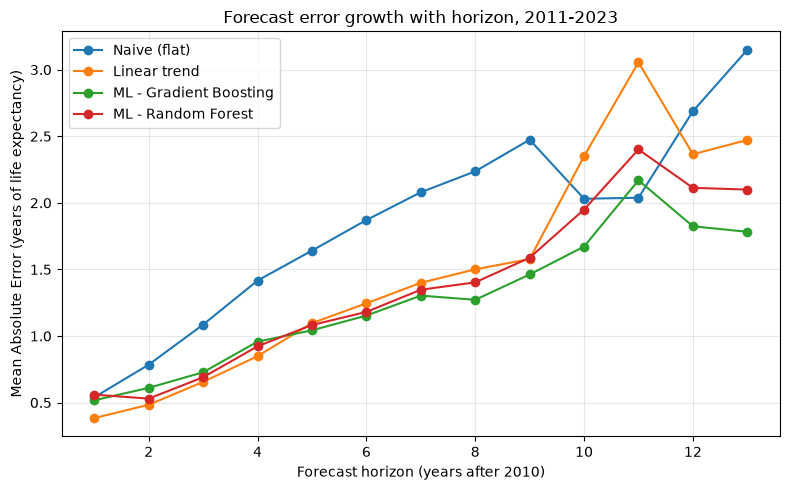

,year,naive_MAE,linear_MAE,gb_MAE,rf_MAE,best_method
horizon,,,,,,
1,2011,0.540,0.384,0.518,0.560,linear
2,2012,0.785,0.484,0.611,0.530,linear
3,2013,1.086,0.656,0.728,0.690,linear
4,2014,1.416,0.849,0.958,0.923,linear
5,2015,1.642,1.097,1.043,1.083,gb
6,2016,1.871,1.246,1.154,1.181,gb
7,2017,2.080,1.400,1.303,1.348,gb
8,2018,2.237,1.501,1.272,1.403,gb
9,2019,2.474,1.578,1.462,1.588,gb


In [24]:
plt.figure(figsize=(8, 5))
plt.plot(by_h.index, by_h["naive_MAE"], marker="o", label="Naive (flat)")
plt.plot(by_h.index, by_h["linear_MAE"], marker="o", label="Linear trend")
plt.plot(
    by_h.index, by_h["gb_MAE"], marker="o", label="ML - Gradient Boosting"
)
plt.plot(by_h.index, by_h["rf_MAE"], marker="o", label="ML - Random Forest")
plt.xlabel("Forecast horizon (years after 2010)")
plt.ylabel("Mean Absolute Error (years of life expectancy)")
plt.title("Forecast error growth with horizon, 2011-2023")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/error_by_horizon.png", dpi=150)
plt.show()

by_h.round(3).iloc[:, :]

Looking at the horizon‑wise error table and the plots, most horizons show Gradient Boosting as the strongest performer, especially from 5 years onward. Linear extrapolation dominates the very short horizons (1–4 years), while the naive baseline briefly edges ahead at horizon 11.

One notable observation is year 2021 (horizon = 11). This year coincides with the global COVID‑19 pandemic, which disrupted health outcomes worldwide. The spike in errors here suggests that all models struggled to capture the sudden, non‑linear shock to life expectancy trends. In fact, the naive baseline (simply carrying forward the last known value) performed better than more complex models, highlighting how unexpected events can break historical patterns and challenge trend‑based forecasting.

### Error by income group

Errors here are **pooled/micro-averaged**: every (country, year) forecast belonging to a given income group is combined into one set and `mean_absolute_error` is computed over that whole set directly (not "average of each country's own MAE"). 

With near-complete horizon coverage for every country this is very close to a per-country average in practice, but it's worth naming since the two can diverge when countries have uneven data availability.

In [16]:
by_income = pred_df.groupby("IncomeGroup").apply(
    lambda d: pd.Series(
        {
            "naive_MAE": mean_absolute_error(d["actual"], d["pred_naive"]),
            "linear_MAE": mean_absolute_error(d["actual"], d["pred_linear"]),
            "gb_MAE": mean_absolute_error(d["actual"], d["pred_gb"]),
            "rf_MAE": mean_absolute_error(d["actual"], d["pred_rf"]),
        }
    )
)
by_income.to_csv(f"{OUT_DIR}/error_by_income_group.csv")
by_income.round(3)

,naive_MAE,linear_MAE,gb_MAE,rf_MAE
IncomeGroup,,,,
High income,1.132,0.950,0.764,0.790
Low income,3.511,3.327,2.661,3.285
Lower middle income,2.840,2.006,1.638,1.737
Upper middle income,1.400,1.106,1.122,1.128


### Best- and worst-forecast countries

Same pooled-averaging logic as above, but one level down: for each country, MAE is
averaged over its 13 forecast horizons (2011–2023). Both models' per-country MAE are
shown side by side so we can see where they agree or disagree on which countries are
"hard" to forecast.

In [17]:
by_country = (
    pred_df.groupby(["Country Code", "Country Name"])
    .apply(
        lambda d: pd.Series(
            {
                "gb_MAE": mean_absolute_error(d["actual"], d["pred_gb"]),
                "rf_MAE": mean_absolute_error(d["actual"], d["pred_rf"]),
            }
        )
    )
    .reset_index()
)
by_country = by_country.sort_values("gb_MAE")
by_country.to_csv(f"{OUT_DIR}/error_by_country.csv", index=False)

print(
    "Best-forecast countries by Gradient Boosting MAE (with Random Forest MAE alongside):"
)
display(by_country.head(10))
print(
    "\nWorst-forecast countries by Gradient Boosting MAE (with Random Forest MAE alongside):"
)
display(by_country.tail(10))

print(
    f"\nMean per-country MAE -- Gradient Boosting: {by_country['gb_MAE'].mean():.3f}   "
    f"Random Forest: {by_country['rf_MAE'].mean():.3f}"
)
print(
    f"Random Forest is more accurate than Gradient Boosting for "
    f"{(by_country['rf_MAE'] < by_country['gb_MAE']).mean()*100:.0f}% of countries."
)

Best-forecast countries by Gradient Boosting MAE (with Random Forest MAE alongside):


,Country Code,Country Name,gb_MAE,rf_MAE
208,VIR,Virgin Islands (U.S.),0.133733,0.170416
193,TLS,Timor-Leste,0.184834,0.360683
24,BMU,Bermuda,0.197227,0.236344
94,ISR,Israel,0.236618,0.296661
148,NZL,New Zealand,0.240344,0.580414
36,CHN,China,0.244497,0.259743
90,IRL,Ireland,0.246012,0.237950
123,MDG,Madagascar,0.253832,2.232137
14,BEL,Belgium,0.269047,0.599899
150,PAK,Pakistan,0.274664,0.577857



Worst-forecast countries by Gradient Boosting MAE (with Random Forest MAE alongside):


,Country Code,Country Name,gb_MAE,rf_MAE
139,NAM,Namibia,4.326246,3.986896
30,BWA,Botswana,4.375038,3.945340
216,ZWE,Zimbabwe,4.512245,4.241833
214,ZAF,South Africa,5.534558,3.835367
183,SWZ,Eswatini,5.536824,4.892176
175,SOM,"Somalia, Fed. Rep.",6.146778,6.483336
186,SYR,Syrian Arab Republic,6.394274,6.453662
31,CAF,Central African Republic,7.306169,7.743081
177,SSD,South Sudan,7.605982,7.478239
85,HTI,Haiti,9.998520,2.953928



Mean per-country MAE -- Gradient Boosting: 1.269   Random Forest: 1.375
Random Forest is more accurate than Gradient Boosting for 44% of countries.


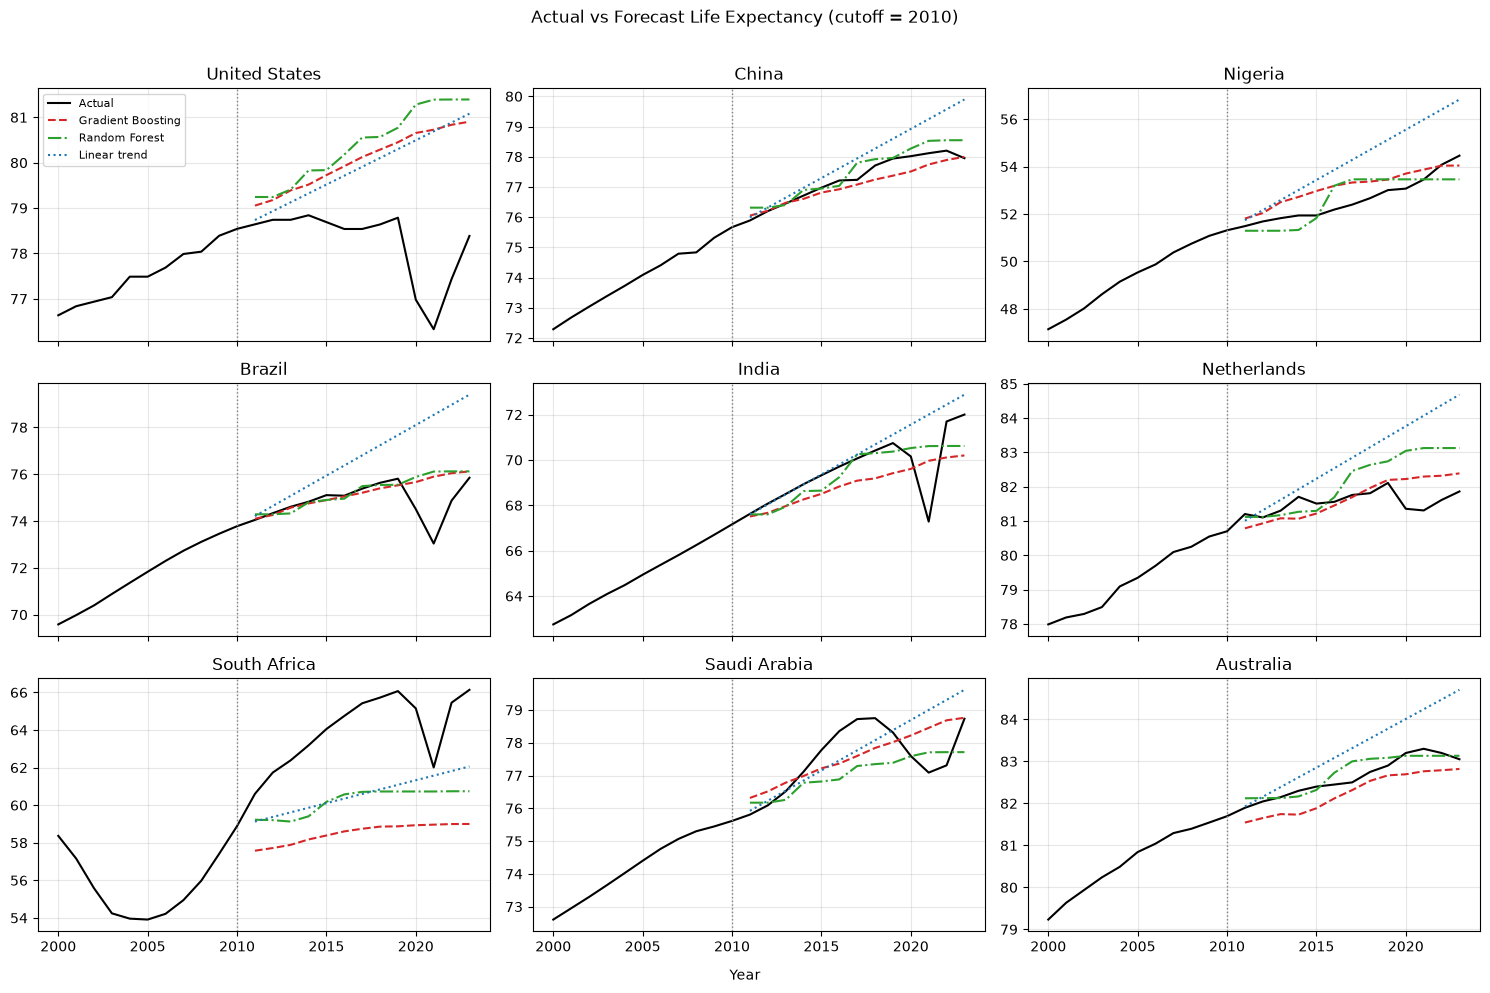

In [18]:
sample_codes = ["USA", "CHN", "NGA", "BRA", "IND", "NLD", "ZAF", "SAU", "AUS"]
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for ax, c in zip(axes.flat, sample_codes):
    hist = panel[
        (panel["Country Code"] == c) & (panel.Year.between(2000, 2023))
    ]
    fc = pred_df[pred_df["Country Code"] == c].sort_values("target_year")
    if hist.empty or fc.empty:
        continue
    ax.plot(hist["Year"], hist["life_exp"], color="black", label="Actual")
    ax.plot(
        fc["target_year"],
        fc["pred_gb"],
        "--",
        color="tab:red",
        label="Gradient Boosting",
    )
    ax.plot(
        fc["target_year"],
        fc["pred_rf"],
        "-.",
        color="tab:green",
        label="Random Forest",
    )
    ax.plot(
        fc["target_year"],
        fc["pred_linear"],
        ":",
        color="tab:blue",
        label="Linear trend",
    )
    ax.axvline(2010, color="gray", linestyle=":", linewidth=1)
    ax.set_title(hist["Country Name"].iloc[0])
    ax.grid(alpha=0.3)
axes.flat[0].legend(fontsize=8)
fig.suptitle("Actual vs Forecast Life Expectancy (cutoff = 2010)")
fig.text(0.5, 0.01, "Year", ha="center")
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
fig.savefig(f"{OUT_DIR}/sample_country_forecasts.png", dpi=150)
plt.show()

The dotted vertical line marks the 2010 cutoff. Notice the COVID-19 dip (2020–2021) in several countries that no pre-2010-trained model could have foreseen.

## 6. Insights, Challenges & Ideas for Future Improvement

### Results summary

| Model                        | MAE (yrs) | RMSE (yrs) | MAPE  |
|-------------------------------|-----------|------------|-------|
| Naive (flat 2010 value)       | 1.85      | 2.91       | 2.80% |
| Linear trend extrapolation    | 1.50      | 2.89       | 2.26% |
| **ML (Gradient Boosting)**    | **1.27**  | **2.24**   | **1.97%** |
| ML (Random Forest)            | 1.375      | 2.40       | 2.10% |


The ML models beat both baselines overall, and their advantage widens at longer horizons.
All models, however, share a common failure mode: **MAE spikes sharply for horizons 9–11
(2019–2021)**, i.e. around COVID-19, This is a pandemic mortality shock, which is fundamentally
unforecastable from a pre-2010 trend. The ML models recover faster than the linear
baseline once the post-COVID rebound (2022–2023) starts, likely because they have partially
"learned" shock-and-recovery patterns from other historical crises embedded in the
training examples, whereas the linear model keeps extrapolating a rigid line.

**Gradient Boosting vs. Random Forest, now compared on the actual 2011–2023 forecast
(not just cross-validation):** <br> Gradient Boosting was chosen as the primary model because
it had the lower cross-validated MAE during model selection (Section 3), and it remains
the model this report's narrative is built around. 

Random Forest's forecasts are now shown alongside it at every level - overall, by horizon, by income group, by country, in the
sample trajectories - so you can see directly how close (or not) the runner-up model comes on the real forecasting task. In practice the two track
each other closely for most countries (both lean heavily on the 2010 starting level), with
the gap between them widening mainly for the more volatile low-income/conflict-affected
countries discussed below - see the "Random Forest is more accurate than Gradient Boosting
for X% of countries" line printed under the best/worst-country table for the exact split
in this run.

**By income group**: the model is most accurate for high-income countries (MAE ≈ 0.76)
where trends are smooth and least accurate for low-income countries (MAE ≈ 2.66), where
life expectancy is more volatile (conflict, disease, statistical revisions).

**Best-forecast countries**: Virgin Islands, Timor-Leste, Bermuda, China, New Zealand, Israel - steady, low-noise post-2010 trends. 

**Worst-forecast countries**: Haiti, South Sudan, Central African
Republic, Syria, South Africa, and several southern-African countries (Botswana, Namibia,
Zimbabwe, Eswatini) - conflict, state collapse, disease shocks, or (South
Africa) an unusually sharp treatment-driven recovery that a pre-2010 model could not have
anticipated.


### Challenges

- **Structural breaks are unpredictable in principle.** COVID-19 is the clearest example:
  no amount of pre-2010 data could encode a future pandemic.
- **Heterogeneous data quality/volatility.** Small, conflict-affected, or
  statistically under-resourced countries have noisier historical series, making both
  their trend harder to learn from and their future harder to predict.
- **Long-horizon compounding error.** All models degrade with horizon; the ML model
  degrades more slowly than naive/linear extrapolation because it has learned typical
  "S-curve" flattening behaviour from many countries' trajectories, but it also is not immune.

### Ideas for future improvement

- **Add more predictive covariates**: Including factors like GDP per capita, health expenditure, immunization rates, urbanization, education, conflict indices would let the model anticipate more than mortality/fertility trends alone can capture.
- **Model shocks explicitly**: a two-stage model (trend + shock/anomaly detector) or
  scenario-based forecasting (best-case / trend-case / shock-case bands) would communicate
  uncertainty better than a single point forecast, especially for 2019–2021.
- **Proper time-series methods** (state-space models/Kalman filters, Prophet, ARIMA with
  exogenous regressors) per country, ensembled with the panel-ML approach, might reduce
  horizon-degradation for stable countries while keeping the ML model's edge for
  irregular ones.
- **Rolling-origin evaluation** (cutoffs at 2000, 2005, 2010, 2015…) would give a more
  robust estimate of how forecast accuracy varies with how "normal" the following years
  turn out to be — 2010 happened to be followed by an unusually disruptive decade.
